# Choi et al. (2021): factorial designs versus Latin hypercube sampling

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | Younhee Choi, Doosam Song, Sungmin Yoon, and Junemo Koo, “Comparison of Factorial and Latin Hypercube Sampling Designs for Meta-Models of Building Heating and Cooling Loads,” *Energies* **14** (2021), 512 |
| DOI | [10.3390/en14020512](https://doi.org/10.3390/en14020512) |
| Open-access route | [Publisher article](https://www.mdpi.com/1996-1073/14/2/512) and [version-of-record PDF](https://mdpi-res.com/d_attachment/energies/energies-14-00512/article_deploy/energies-14-00512-v2.pdf) |
| Licence | Creative Commons Attribution 4.0 (CC BY 4.0), stated on page 1 |
| Citation snapshot | 56 citations in [OpenAlex record W3123703295](https://openalex.org/W3123703295), retrieved 2026-08-01 |
| Reproduction level | **Level C — methodological reproduction** |
| Core tools | `pydoe`, NumPy, pandas, Matplotlib |
| Random seed | 20210801 |
| Source PDF checksum | SHA-256 `d71d000a2f28ccbda95008a58d34e70dbf7c8d916f9ce273d769c1a6ec8d59c0` |

> **Important limitation.** The paper says that its data are available *on request*; it does not distribute the 3,072 TRNSYS responses (1,024 factorial points plus 2,048 LHS points), the simulator files, the random seed, the exact fractional-factor generators, or the stepwise-selection trace. Therefore this notebook does **not** invent or claim to reproduce building-load observations.

What is reproduced faithfully:

- the ten factors, ranges, special three-level handling of WDI and SHGC, and reported sampling/validation budgets;
- the two-level factorial and LHS design logic using the same Python design package family cited by the paper;
- the estimability result explaining why factorial meta-models a-1 and a-2 coincide;
- every adjusted/prediction $R^2$ value in Tables 5 and 6, transcribed as published evidence;
- the article's central design claim, tested independently on a documented synthetic response with equal budgets and repeated LHS seeds.

What cannot be reproduced exactly: TRNSYS loads, Figure 4 errors, Appendix A stepwise coefficients, Figures 5–10, and the exact sampled rows. This separation makes the notebook executable and useful without misrepresenting unavailable evidence.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/choi2021-matplotlib")

import importlib.metadata as metadata
import itertools
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydoe import ff2n, lhs

SEED = 20210801
RNG = np.random.default_rng(SEED)
EXECUTION_DATE = "2026-08-01"

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.spines.top": False,
                     "axes.spines.right": False})

## 1. Scientific context

The experimental unit is one deterministic annual **TRNSYS simulation of an office floor in Seoul**. A treatment is a complete envelope design; the responses are annual heating and cooling loads in kWh m$^{-2}$ yr$^{-1}$. Weather, occupancy, internal gains, schedules, and temperature set points were held fixed. There are no physical replicates, blocks, or pure-error degrees of freedom. Simulation run order has no physical carry-over effect, although random row order is still useful operationally.

The scientific question is predictive: which sampling design gives a meta-model that works at *arbitrary points inside* the ten-dimensional design region? A two-level factorial samples corners efficiently and estimates main effects and two-factor interactions, but it cannot distinguish a pure quadratic $x_j^2$ from the intercept because $x_j^2=1$ at every corner. LHS spreads simulations through the interior and can therefore reveal curvature.

The paper generated 2,048 LHS treatments, used 1,024 as a model-building pool and 1,024 for validation, and drew nested training subsets of 128, 256, and 512. Its FFD models used 128, 256, or 512 points and an excluded 512-point factorial validation half. WDI and SHGC were restricted to three implementable window levels; the other eight variables were continuous for LHS.

In [2]:
factor_info = pd.DataFrame([
    ("FA", "Floor area", "m²", 1000.0, 2000.0, "continuous"),
    ("AR", "Aspect ratio", "–", 1.0, 2.0, "continuous"),
    ("OR", "Orientation", "degrees", 0.0, 90.0, "continuous"),
    ("WWR", "Window-to-wall ratio", "%", 25.0, 52.0, "continuous"),
    ("CH", "Ceiling height", "m", 2.4, 2.9, "continuous"),
    ("PH", "Plenum height", "m", 0.8, 1.2, "continuous"),
    ("WI", "Wall insulation (U-value)", "W m⁻² K⁻¹", 0.15, 0.36, "continuous"),
    ("WDI", "Window insulation (U-value)", "W m⁻² K⁻¹", 0.75, 2.84, "3 levels: 0.75, 1.70, 2.84"),
    ("SHGC", "Solar heat gain coefficient", "%", 20.0, 70.0, "3 levels: 20, 40, 70"),
    ("ACR", "Air leakage", "ACH", 0.1, 0.3, "continuous"),
], columns=["code", "factor", "unit", "low", "high", "LHS implementation"])

assert len(factor_info) == 10
assert (factor_info["high"] > factor_info["low"]).all()
factor_info

,code,factor,unit,low,high,LHS implementation
0,FA,Floor area,m²,1000.00,2000.00,continuous
1,AR,Aspect ratio,–,1.00,2.00,continuous
2,OR,Orientation,degrees,0.00,90.00,continuous
3,WWR,Window-to-wall ratio,%,25.00,52.00,continuous
4,CH,Ceiling height,m,2.40,2.90,continuous
5,PH,Plenum height,m,0.80,1.20,continuous
6,WI,Wall insulation (U-value),W m⁻² K⁻¹,0.15,0.36,continuous
7,WDI,Window insulation (U-value),W m⁻² K⁻¹,0.75,2.84,"3 levels: 0.75, 1.70, 2.84"
8,SHGC,Solar heat gain coefficient,%,20.00,70.00,"3 levels: 20, 40, 70"
9,ACR,Air leakage,ACH,0.10,0.30,continuous


## 2. Data provenance and reproduction boundary

The article PDF was read in full. Tables 3–6 and the text surrounding Figures 2–6 are the sources used here. Table 3 supplies factor bounds; Table 4 supplies the eight sampling/model/validation cases; Tables 5 and 6 supply $R^2$ targets. The paper's data-availability statement says: “The data presented in this study are available on request from the corresponding author.” No public supplement or repository containing run-level responses is linked.

Consequences:

- the factor table and reported aggregate values below are **manual transcriptions** and are checked structurally;
- generated rows are a valid reconstruction of the stated designs, not the authors' undisclosed random rows;
- the later response benchmark is prominently labelled **synthetic teaching evidence**;
- no new building simulation or laboratory work is implied.

The article used stepwise regression in R. Its precise candidate hierarchy, entry/removal thresholds, and selection trace are not reported. Repeating automated selection on invented responses would create false precision, so this notebook instead studies the estimability of a transparent hierarchical model: intercept, ten main effects, all 45 two-factor interactions, and (where estimable) ten pure quadratic terms.

## 3. Reconstruct the design

### 3.1 Nested two-level fractions

`pydoe.ff2n(10)` generates the $2^{10}=1{,}024$ corner design. The paper omits its fractional generators. We therefore create one transparent, nested resolution-V family by selecting the positive fraction for three independent defining words:

- $I=ABCDE$ gives 512 training corners; its negative half is the 512-point validation set;
- adding $I=ABFGH$ gives 256 points;
- adding $I=ACFIJ$ gives 128 points.

Every non-identity word in the resulting defining contrast subgroup has length at least five. Main effects are therefore not aliased with two-factor interactions, and two-factor interactions are not aliased with one another. Other resolution-V generators could select different rows; the paper does not provide enough information to identify its exact choice.

In [3]:
FACTOR_NAMES = factor_info["code"].tolist()
full_factorial = ff2n(len(FACTOR_NAMES)).astype(float)

word_indices = {
    "ABCDE": [0, 1, 2, 3, 4],
    "ABFGH": [0, 1, 5, 6, 7],
    "ACFIJ": [0, 2, 5, 8, 9],
}

def word_sign(design, indices):
    return np.prod(design[:, indices], axis=1)

mask_512 = word_sign(full_factorial, word_indices["ABCDE"]) > 0
mask_256 = mask_512 & (word_sign(full_factorial, word_indices["ABFGH"]) > 0)
mask_128 = mask_256 & (word_sign(full_factorial, word_indices["ACFIJ"]) > 0)

ffd_train = {
    128: full_factorial[mask_128],
    256: full_factorial[mask_256],
    512: full_factorial[mask_512],
}
ffd_validation = full_factorial[~mask_512]

def snap_window_columns(coded):
    # Map randomized LHS coordinates to the paper's three feasible WDI/SHGC levels.
    out = np.asarray(coded, float).copy()
    for j in [7, 8]:
        out[:, j] = np.where(out[:, j] < -1/3, -1.0,
                    np.where(out[:, j] < 1/3, 0.0, 1.0))
    return out

lhs_master_u = lhs(10, samples=2048, seed=SEED)
lhs_master = snap_window_columns(2 * lhs_master_u - 1)
lhs_pool = lhs_master[:1024]
lhs_validation = lhs_master[1024:]
lhs_train = {n: lhs_pool[:n] for n in [128, 256, 512, 1024]}

def decode(coded):
    coded = np.asarray(coded, float)
    low = factor_info["low"].to_numpy()
    high = factor_info["high"].to_numpy()
    physical = low + (coded + 1) * (high - low) / 2
    physical[:, 7] = np.select(
        [coded[:, 7] < -0.5, coded[:, 7] < 0.5], [0.75, 1.70], default=2.84)
    physical[:, 8] = np.select(
        [coded[:, 8] < -0.5, coded[:, 8] < 0.5], [20.0, 40.0], default=70.0)
    return pd.DataFrame(physical, columns=FACTOR_NAMES)

assert full_factorial.shape == (1024, 10)
assert {n: len(x) for n, x in ffd_train.items()} == {128: 128, 256: 256, 512: 512}
assert len(ffd_validation) == 512
assert len(lhs_pool) == len(lhs_validation) == 1024
assert all(set(np.unique(lhs_master[:, j])).issubset({-1.0, 0.0, 1.0}) for j in [7, 8])

print("Generated design counts:")
display(pd.DataFrame({
    "design": ["full factorial", "FFD train", "FFD train", "FFD train", "FFD validation",
               "LHS master", "LHS model pool", "LHS validation"],
    "runs": [1024, 128, 256, 512, 512, 2048, 1024, 1024],
}))
print("First five reconstructed LHS treatments in physical units (not published run identities):")
decode(lhs_train[128]).head()

Generated design counts:


,design,runs
0,full factorial,1024
1,FFD train,128
2,FFD train,256
3,FFD train,512
4,FFD validation,512
5,LHS master,2048
6,LHS model pool,1024
7,LHS validation,1024


First five reconstructed LHS treatments in physical units (not published run identities):


,FA,AR,OR,WWR,CH,PH,WI,WDI,SHGC,ACR
0,1778.2570,1.7757,10.5246,27.4898,2.4216,0.8418,0.2028,2.84,20.0,0.1766
1,1610.0180,1.3076,0.4355,46.0792,2.6130,1.1834,0.2240,0.75,20.0,0.1074
2,1692.5298,1.7852,67.6421,31.9786,2.8860,1.0967,0.2774,2.84,70.0,0.2916
3,1159.9785,1.5775,27.7140,37.3012,2.5208,0.8533,0.3577,2.84,20.0,0.2782
4,1829.5460,1.8754,12.9264,50.5241,2.5448,0.9474,0.1546,2.84,40.0,0.1383


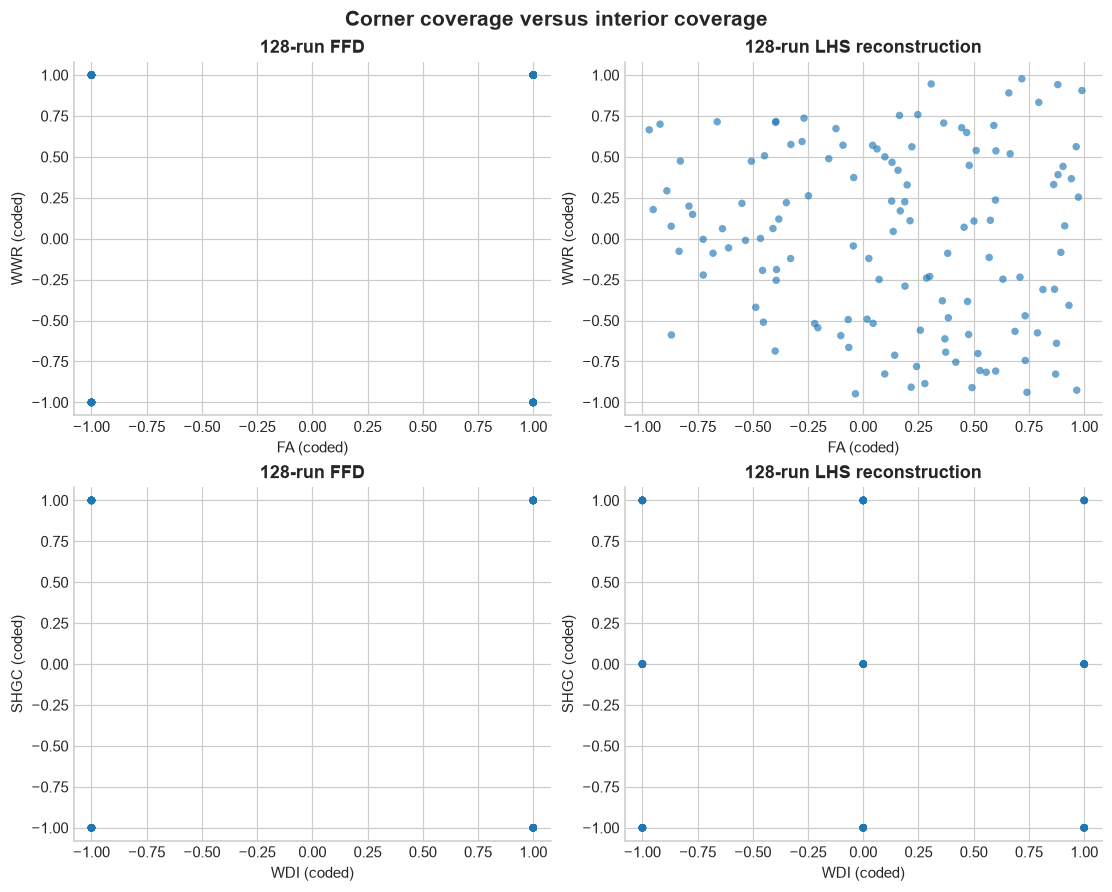

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
projections = [(0, 3, "FA (coded)", "WWR (coded)"),
               (7, 8, "WDI (coded)", "SHGC (coded)")]
for row, (i, j, xlabel, ylabel) in enumerate(projections):
    for col, (label, design) in enumerate([("128-run FFD", ffd_train[128]),
                                            ("128-run LHS reconstruction", lhs_train[128])]):
        ax = axes[row, col]
        ax.scatter(design[:, i], design[:, j], s=24, alpha=0.65, edgecolor="none")
        ax.set(title=label, xlabel=xlabel, ylabel=ylabel, xlim=(-1.08, 1.08), ylim=(-1.08, 1.08))
fig.suptitle("Corner coverage versus interior coverage", fontsize=14, fontweight="bold")
plt.show()

The FFD projection contains only corners. The LHS reconstruction occupies the interior for continuous variables, while WDI and SHGC deliberately form a $3\times3$ grid because those two inputs were restricted by available window specifications. Snapping those columns means this is no longer a strict ten-column Latin hypercube; it is a pragmatic mixed-level space-filling design, matching the constraint described by the authors.

## 4. Understand the design

For ten factors, a hierarchical main-plus-two-factor-interaction model has

$$1 + 10 + \binom{10}{2}=56$$

columns. Adding ten pure quadratics gives 66 columns. Rank asks whether those coefficients carry distinct information. A condition number measures how strongly numerical noise can be amplified; values near one are exceptionally stable, while very large values warn that small response changes can create large coefficient changes. Here columns are scaled to unit length before the condition number is calculated, so it reflects geometry rather than arbitrary units.

In [5]:
PAIRS = list(itertools.combinations(range(10), 2))

def model_matrix(x, quadratic=False):
    x = np.asarray(x, float)
    columns = [np.ones(len(x))]
    names = ["Intercept"]
    columns.extend(x[:, j] for j in range(10))
    names.extend(FACTOR_NAMES)
    columns.extend(x[:, i] * x[:, j] for i, j in PAIRS)
    names.extend(f"{FACTOR_NAMES[i]}:{FACTOR_NAMES[j]}" for i, j in PAIRS)
    if quadratic:
        columns.extend(x[:, j] ** 2 for j in range(10))
        names.extend(f"{name}²" for name in FACTOR_NAMES)
    return np.column_stack(columns), names

def scaled_condition(x):
    norms = np.linalg.norm(x, axis=0)
    xs = x[:, norms > 1e-12] / norms[norms > 1e-12]
    s = np.linalg.svd(xs, compute_uv=False)
    rank = np.linalg.matrix_rank(xs)
    return np.inf if rank < xs.shape[1] else s[0] / s[-1]

def max_main_correlation(x):
    corr = np.corrcoef(np.asarray(x), rowvar=False)
    return np.max(np.abs(corr[np.triu_indices_from(corr, k=1)]))

diagnostic_rows = []
for design_name, designs in [("FFD", ffd_train), ("LHS", lhs_train)]:
    for n in [128, 256, 512]:
        x = designs[n]
        lin, _ = model_matrix(x, quadratic=False)
        quad, _ = model_matrix(x, quadratic=True)
        diagnostic_rows.append({
            "design": design_name, "runs": n,
            "rank linear / 56": np.linalg.matrix_rank(lin),
            "rank quadratic / 66": np.linalg.matrix_rank(quad),
            "quadratic condition": scaled_condition(quad),
            "max |main correlation|": max_main_correlation(x),
            "mean |coded coordinate|": np.mean(np.abs(x)),
        })
diagnostics = pd.DataFrame(diagnostic_rows)
diagnostics

,design,runs,rank linear / 56,rank quadratic / 66,quadratic condition,max |main correlation|,mean |coded coordinate|
0,FFD,128,56,56,inf,0.0000,1.0000
1,FFD,256,56,56,inf,0.0000,1.0000
2,FFD,512,56,56,inf,0.0000,1.0000
3,LHS,128,56,66,16.9753,0.2114,0.5279
4,LHS,256,56,66,13.8796,0.1438,0.5349
5,LHS,512,56,66,12.3141,0.1757,0.5336


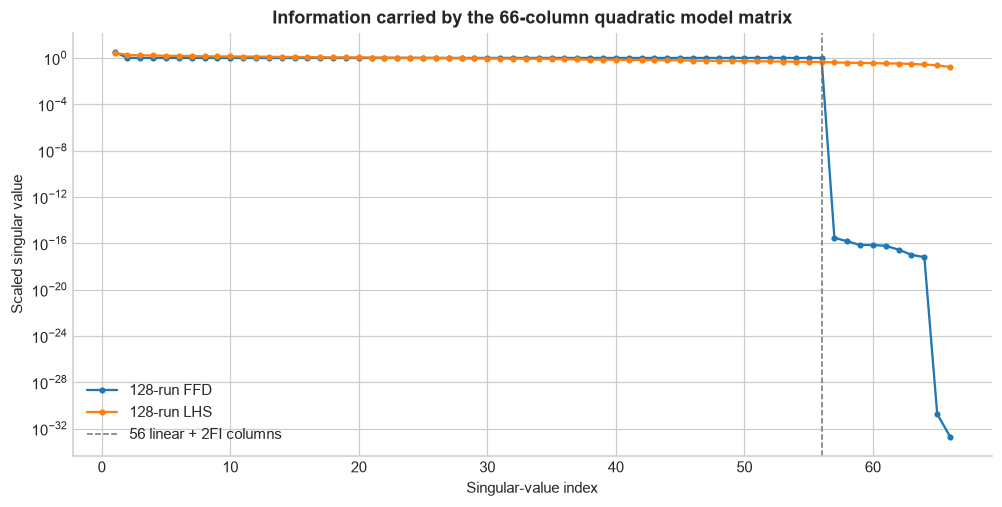

In [6]:
quad_ffd, quad_names = model_matrix(ffd_train[128], quadratic=True)
quad_lhs, _ = model_matrix(lhs_train[128], quadratic=True)

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
for label, matrix in [("128-run FFD", quad_ffd), ("128-run LHS", quad_lhs)]:
    singular = np.linalg.svd(matrix / np.linalg.norm(matrix, axis=0), compute_uv=False)
    ax.semilogy(np.arange(1, len(singular) + 1), singular, marker="o", ms=3, label=label)
ax.axvline(56, color="0.45", ls="--", lw=1, label="56 linear + 2FI columns")
ax.set(title="Information carried by the 66-column quadratic model matrix",
       xlabel="Singular-value index", ylabel="Scaled singular value")
ax.legend()
plt.show()

The resolution-V FFD estimates all 56 linear-plus-interaction coefficients cleanly. Its ten square columns are all copies of the intercept, so the 66-column matrix still has rank 56 and ten singular values collapse to numerical zero. This is the algebraic reason the paper obtained the same equation for meta-models a-1 and a-2.

The LHS matrix has rank 66 even at 128 runs. Its coefficients are less orthogonal than the regular fraction, but the design contains the intermediate levels needed to separate curvature from the intercept. **Estimable does not mean important**: deciding which square terms matter requires responses and uncertainty, which are unavailable here.

## 5. Reproduce the article analysis

The next two tables are the article's Tables 5 and 6 transcribed exactly. They are evidence, not recomputed results. “Fitting” evaluates the data used to construct a meta-model; “prediction” evaluates an excluded design. The contrast between validation geometries is the central result: a corner-trained FFD predicts corners very well, but LHS plus square terms performs best on an interior-spread LHS validation set.

In [7]:
table5 = pd.DataFrame([
    (128, 0.9966, 0.9959, 0.8585, 0.9517, 0.9951, 0.9968, 0.9940, 0.9935, 0.6731, 0.8918, 0.9806, 0.9909),
    (256, 0.9971, 0.9963, 0.8023, 0.9423, 0.9929, 0.9966, 0.9956, 0.9943, 0.7943, 0.9382, 0.9917, 0.9960),
    (512, 0.9968, 0.9960, 0.8126, 0.9398, 0.9926, 0.9966, 0.9964, 0.9950, 0.8224, 0.9443, 0.9929, 0.9966),
    (1024, np.nan, np.nan, 0.8263, 0.9446, 0.9926, 0.9968, np.nan, np.nan, 0.8312, 0.9469, 0.9935, 0.9970),
], columns=["runs", "fit_a1_HL", "fit_a1_CL", "fit_b1_HL", "fit_b1_CL",
            "fit_b2_HL", "fit_b2_CL", "pred_1-1_HL", "pred_1-1_CL",
            "pred_1-3_HL", "pred_1-3_CL", "pred_1-4_HL", "pred_1-4_CL"])

table6 = pd.DataFrame([
    (128, 0.6917, 0.9220, 0.6497, 0.8733, 0.9752, 0.9889),
    (256, 0.6959, 0.9235, 0.7753, 0.9266, 0.9911, 0.9955),
    (512, 0.6967, 0.9233, 0.7940, 0.9340, 0.9910, 0.9960),
    (1024, np.nan, np.nan, 0.8089, 0.9379, 0.9911, 0.9964),
], columns=["runs", "pred_2-1_HL", "pred_2-1_CL", "pred_2-3_HL", "pred_2-3_CL",
            "pred_2-4_HL", "pred_2-4_CL"])

assert table5.shape == (4, 13) and table6.shape == (4, 7)
assert table5.loc[table5.runs == 128, ["pred_1-3_HL", "pred_1-3_CL"]].iloc[0].tolist() == [0.6731, 0.8918]
assert table6.loc[table6.runs == 512, ["pred_2-4_HL", "pred_2-4_CL"]].iloc[0].tolist() == [0.9910, 0.9960]

print("Published Table 5 — FFD validation data")
display(table5)
print("Published Table 6 — LHS validation data")
display(table6)

Published Table 5 — FFD validation data


,runs,fit_a1_HL,fit_a1_CL,fit_b1_HL,fit_b1_CL,fit_b2_HL,fit_b2_CL,pred_1-1_HL,pred_1-1_CL,pred_1-3_HL,pred_1-3_CL,pred_1-4_HL,pred_1-4_CL
0,128,0.9966,0.9959,0.8585,0.9517,0.9951,0.9968,0.9940,0.9935,0.6731,0.8918,0.9806,0.9909
1,256,0.9971,0.9963,0.8023,0.9423,0.9929,0.9966,0.9956,0.9943,0.7943,0.9382,0.9917,0.9960
2,512,0.9968,0.9960,0.8126,0.9398,0.9926,0.9966,0.9964,0.9950,0.8224,0.9443,0.9929,0.9966
3,1024,NaN,NaN,0.8263,0.9446,0.9926,0.9968,NaN,NaN,0.8312,0.9469,0.9935,0.9970


Published Table 6 — LHS validation data


,runs,pred_2-1_HL,pred_2-1_CL,pred_2-3_HL,pred_2-3_CL,pred_2-4_HL,pred_2-4_CL
0,128,0.6917,0.9220,0.6497,0.8733,0.9752,0.9889
1,256,0.6959,0.9235,0.7753,0.9266,0.9911,0.9955
2,512,0.6967,0.9233,0.7940,0.9340,0.9910,0.9960
3,1024,NaN,NaN,0.8089,0.9379,0.9911,0.9964


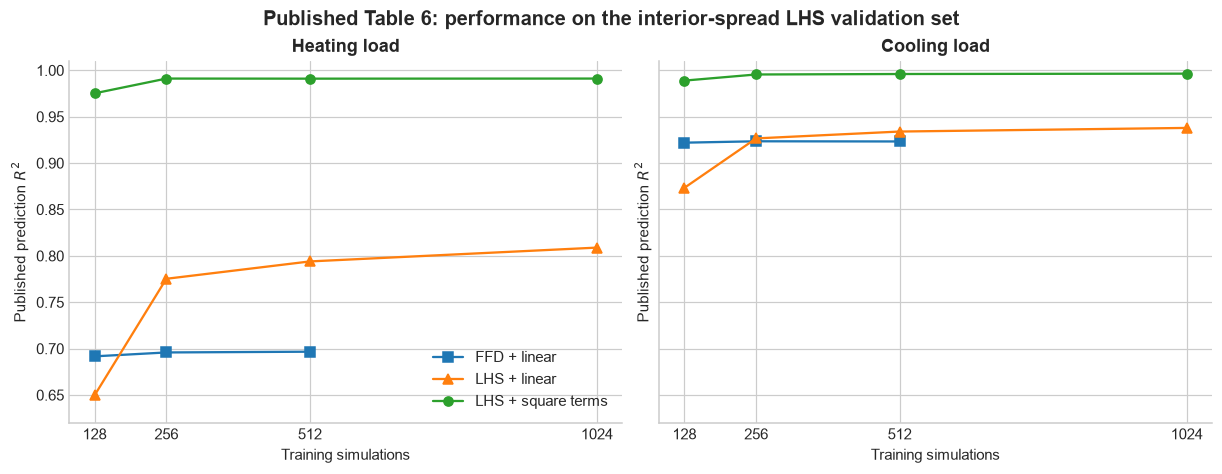

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True, constrained_layout=True)
for ax, response, suffix in zip(axes, ["Heating load", "Cooling load"], ["HL", "CL"]):
    for case, label, marker in [("2-1", "FFD + linear", "s"),
                                ("2-3", "LHS + linear", "^"),
                                ("2-4", "LHS + square terms", "o")]:
        col = f"pred_{case}_{suffix}"
        valid = table6[["runs", col]].dropna()
        ax.plot(valid["runs"], valid[col], marker=marker, label=label)
    ax.set(title=response, xlabel="Training simulations", ylabel="Published prediction $R^2$",
           xticks=[128, 256, 512, 1024], ylim=(0.62, 1.01))
axes[0].legend(loc="lower right")
fig.suptitle("Published Table 6: performance on the interior-spread LHS validation set",
             fontsize=13, fontweight="bold")
plt.show()

### A suspected metric erratum worth noticing

The prose and Figure 4 call the error **RMSE**, but Equation (2) prints

$$\frac{\sum_i \sqrt{(y_i-x_i)^2}}{n},$$

which is mean absolute error (MAE), because $\sqrt{e_i^2}=|e_i|$. Conventional RMSE is

$$\sqrt{\frac{\sum_i (y_i-x_i)^2}{n}}.$$

The two are not interchangeable. Without the response rows or analysis script, one cannot determine whether only the equation was typeset incorrectly or Figure 4 was calculated with MAE. The notebook therefore does not transcribe approximate points from the figure as exact validation targets, and the synthetic comparison reports both metrics with their conventional definitions.

In [9]:
toy_residuals = np.array([3.0, 4.0])
metric_demo = pd.Series({
    "paper Equation (2), algebraically MAE": np.mean(np.abs(toy_residuals)),
    "conventional RMSE": np.sqrt(np.mean(toy_residuals ** 2)),
})
metric_demo.to_frame("value for residuals [3, 4]")

,"value for residuals [3, 4]"
"paper Equation (2), algebraically MAE",3.5000
conventional RMSE,3.5355


## 6. Validate against the paper

The design-level targets can be regenerated exactly. The response-level targets can only be checked as faithful transcriptions because the underlying TRNSYS rows are absent. “Difference = 0” in the last two rows means the stored value matches the cited printed table; it does **not** mean the regression was rerun.

In [10]:
validation = pd.DataFrame([
    ("Full two-level factorial runs", 1024, len(full_factorial), 0, "exact algebra: 2¹⁰"),
    ("FFD model-building budgets", "128/256/512", "/".join(map(str, sorted(ffd_train))), 0, "valid nested resolution-V reconstruction"),
    ("FFD validation runs", 512, len(ffd_validation), 0, "complementary half fraction"),
    ("LHS master runs", 2048, len(lhs_master), 0, "pydoe.lhs, exact stated budget"),
    ("LHS model / validation split", "1024/1024", f"{len(lhs_pool)}/{len(lhs_validation)}", 0, "exact stated split"),
    ("FFD a-1 / a-2 model rank at n=512", "same equation", f"{np.linalg.matrix_rank(model_matrix(ffd_train[512], False)[0])}/{np.linalg.matrix_rank(model_matrix(ffd_train[512], True)[0])}", 0, "both ranks are 56; squares duplicate intercept"),
    ("Table 5, case 1-3 at n=128 (HL/CL)", "0.6731/0.8918", f"{table5.iloc[0]['pred_1-3_HL']:.4f}/{table5.iloc[0]['pred_1-3_CL']:.4f}", 0, "checked transcription only"),
    ("Table 6, case 2-4 at n=512 (HL/CL)", "0.9910/0.9960", f"{table6.iloc[2]['pred_2-4_HL']:.4f}/{table6.iloc[2]['pred_2-4_CL']:.4f}", 0, "checked transcription only"),
], columns=["target", "published", "notebook", "absolute difference", "interpretation"])
validation

,target,published,notebook,absolute difference,interpretation
0,Full two-level factorial runs,1024,1024,0,exact algebra: 2¹⁰
1,FFD model-building budgets,128/256/512,128/256/512,0,valid nested resolution-V reconstruction
2,FFD validation runs,512,512,0,complementary half fraction
3,LHS master runs,2048,2048,0,"pydoe.lhs, exact stated budget"
4,LHS model / validation split,1024/1024,1024/1024,0,exact stated split
5,FFD a-1 / a-2 model rank at n=512,same equation,56/56,0,both ranks are 56; squares duplicate intercept
6,"Table 5, case 1-3 at n=128 (HL/CL)",0.6731/0.8918,0.6731/0.8918,0,checked transcription only
7,"Table 6, case 2-4 at n=512 (HL/CL)",0.9910/0.9960,0.9910/0.9960,0,checked transcription only


## 7. Go beyond the paper

This section is a **synthetic teaching demonstration, not building evidence**. It asks whether the article's qualitative result follows from geometry alone.

The documented response has ten coded inputs, main effects, and three two-factor interactions. Its “curved” version adds smooth curvature concentrated in WDI and SHGC plus a small higher-order remainder. The curvature is constructed to be zero at factorial corners, so a corner-only validation set cannot reveal it. There is no noise: errors isolate design/model mismatch rather than stochastic variation.

For each budget (128, 256, 512):

- the fixed FFD is fitted with the estimable 56-column linear-plus-interaction model;
- 20 independently seeded, paper-shaped LHS master designs are generated and subset; both linear and 66-column quadratic models are fitted;
- all models face the same 1,024 factorial-corner validation points and the same independent 4,096-point mixed-level interior validation design;
- conventional RMSE and MAE are reported separately.

This is deliberately restrained: no hyperparameter search, random train/test split, proprietary simulator, or response-driven design tuning.

In [11]:
def synthetic_loads(x, curved=True):
    # Paper-shaped deterministic teaching functions; values are not TRNSYS outputs.
    x = np.asarray(x, float)
    heat_beta = np.array([1.8, -0.8, -0.3, 1.2, 1.4, 0.5, 1.1, 4.2, -2.8, 5.5])
    cool_beta = np.array([2.4, -1.1, -0.8, 2.8, -0.7, -0.4, -1.2, -2.0, 6.0, -2.2])
    heat = 25 + x @ heat_beta + 1.4*x[:, 7]*x[:, 8] + 0.9*x[:, 3]*x[:, 7] + 0.7*x[:, 0]*x[:, 4]
    cool = 65 + x @ cool_beta + 2.2*x[:, 7]*x[:, 8] - 1.1*x[:, 3]*x[:, 8] + 0.8*x[:, 0]*x[:, 4]
    if curved:
        heat += 5.0*(1-x[:, 7]**2) + 3.0*(1-x[:, 8]**2) + 1.0*(1-x[:, 7]**2)*x[:, 8]
        cool += 2.5*(1-x[:, 7]**2) + 6.0*(1-x[:, 8]**2) + 1.2*(1-x[:, 8]**2)*x[:, 7]
    return np.column_stack([heat, cool])

def fit_predict(x_train, y_train, x_test, quadratic):
    a_train, _ = model_matrix(x_train, quadratic=quadratic)
    a_test, _ = model_matrix(x_test, quadratic=quadratic)
    coef, *_ = np.linalg.lstsq(a_train, y_train, rcond=None)
    return a_test @ coef

def metrics(y, pred):
    residual = np.asarray(pred) - np.asarray(y)
    return np.sqrt(np.mean(residual**2, axis=0)), np.mean(np.abs(residual), axis=0)

interior_validation = snap_window_columns(2 * lhs(10, samples=4096, seed=SEED + 9000) - 1)
endpoint_validation = full_factorial

# Sanity check: when the truth really is linear + 2FI, either design recovers it.
linear_truth = synthetic_loads(interior_validation, curved=False)
linear_check = []
for label, train in [("FFD", ffd_train[128]), ("LHS", lhs_train[128])]:
    pred = fit_predict(train, synthetic_loads(train, curved=False), interior_validation, quadratic=False)
    linear_check.append((label, metrics(linear_truth, pred)[0].max()))
pd.DataFrame(linear_check, columns=["128-run design", "maximum response RMSE for linear truth"])

,128-run design,maximum response RMSE for linear truth
0,FFD,1.5483e-14
1,LHS,1.0053e-13


In [12]:
benchmark_rows = []
responses = ["Heating", "Cooling"]
validation_sets = {"factorial corners": endpoint_validation, "mixed-level interior": interior_validation}

def append_result(design, model, budget, repeat, validation_name, y_true, pred):
    rmse, mae = metrics(y_true, pred)
    for j, response in enumerate(responses):
        benchmark_rows.append({"design": design, "model": model, "budget": budget,
            "repeat": repeat, "validation": validation_name, "response": response,
            "RMSE": rmse[j], "MAE": mae[j]})

for budget in [128, 256, 512]:
    train = ffd_train[budget]
    y_train = synthetic_loads(train, curved=True)
    for validation_name, test in validation_sets.items():
        append_result("FFD", "linear + 2FI", budget, -1, validation_name,
                      synthetic_loads(test, curved=True),
                      fit_predict(train, y_train, test, quadratic=False))

for repeat in range(20):
    master = snap_window_columns(2 * lhs(10, samples=2048, seed=SEED + 100 + repeat) - 1)
    pool = master[:1024]
    for budget in [128, 256, 512]:
        train = pool[:budget]
        y_train = synthetic_loads(train, curved=True)
        for model, quadratic in [("linear + 2FI", False), ("quadratic", True)]:
            for validation_name, test in validation_sets.items():
                append_result("LHS", model, budget, repeat, validation_name,
                              synthetic_loads(test, curved=True),
                              fit_predict(train, y_train, test, quadratic=quadratic))

benchmark = pd.DataFrame(benchmark_rows)
summary = (benchmark.groupby(["validation", "response", "design", "model", "budget"])
           .agg(median_RMSE=("RMSE", "median"), min_RMSE=("RMSE", "min"),
                max_RMSE=("RMSE", "max"), median_MAE=("MAE", "median"), repeats=("repeat", "count"))
           .reset_index())
summary.query("validation == 'mixed-level interior' and budget == 512")

,validation,response,design,model,budget,median_RMSE,min_RMSE,max_RMSE,median_MAE,repeats
20,mixed-level interior,Cooling,FFD,linear + 2FI,512,4.1856,4.1856,4.1856,2.8247,1
23,mixed-level interior,Cooling,LHS,linear + 2FI,512,3.2540,3.1790,3.3604,2.7661,20
26,mixed-level interior,Cooling,LHS,quadratic,512,0.5002,0.4875,0.5054,0.4015,20
29,mixed-level interior,Heating,FFD,linear + 2FI,512,3.8416,3.8416,3.8416,2.6653,1
32,mixed-level interior,Heating,LHS,linear + 2FI,512,2.9211,2.8412,2.9978,2.4414,20
35,mixed-level interior,Heating,LHS,quadratic,512,0.4135,0.4033,0.4253,0.3346,20


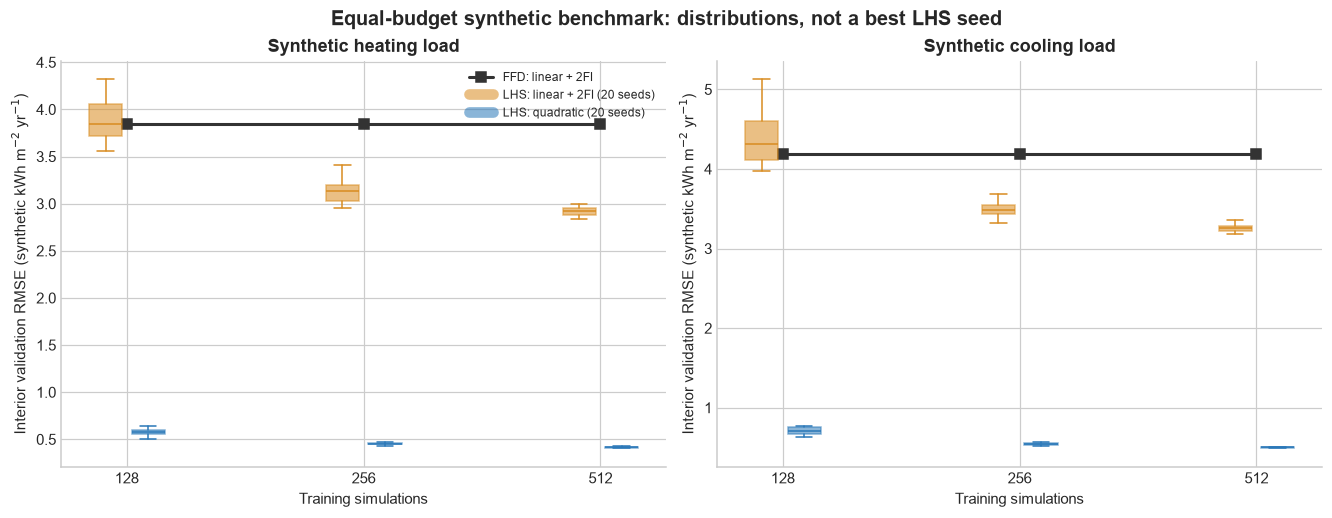

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False, constrained_layout=True)
colors = {("LHS", "linear + 2FI"): "#d98c20", ("LHS", "quadratic"): "#2a78b8"}

for ax, response in zip(axes, responses):
    sub = benchmark.query("validation == 'mixed-level interior' and response == @response")
    positions = np.arange(3)
    ffd = sub.query("design == 'FFD'").sort_values("budget")
    ax.plot(positions, ffd["RMSE"], color="#333333", marker="s", lw=2, label="FFD: linear + 2FI")
    offsets = {"linear + 2FI": -0.09, "quadratic": 0.09}
    for model in ["linear + 2FI", "quadratic"]:
        groups = [sub.query("design == 'LHS' and model == @model and budget == @b")["RMSE"].to_numpy()
                  for b in [128, 256, 512]]
        bp = ax.boxplot(groups, positions=positions + offsets[model], widths=0.14,
                        patch_artist=True, showfliers=False, manage_ticks=False)
        color = colors[("LHS", model)]
        for box in bp["boxes"]: box.set(facecolor=color, alpha=0.55, edgecolor=color)
        for part in ["whiskers", "caps", "medians"]:
            for artist in bp[part]: artist.set(color=color)
        ax.plot([], [], color=color, lw=7, alpha=0.55, label=f"LHS: {model} (20 seeds)")
    ax.set(title=f"Synthetic {response.lower()} load", xlabel="Training simulations",
           ylabel=r"Interior validation RMSE (synthetic kWh m$^{-2}$ yr$^{-1}$)", xticks=positions,
           xticklabels=[128, 256, 512])
axes[0].legend(fontsize=8)
fig.suptitle("Equal-budget synthetic benchmark: distributions, not a best LHS seed",
             fontsize=13, fontweight="bold")
plt.show()

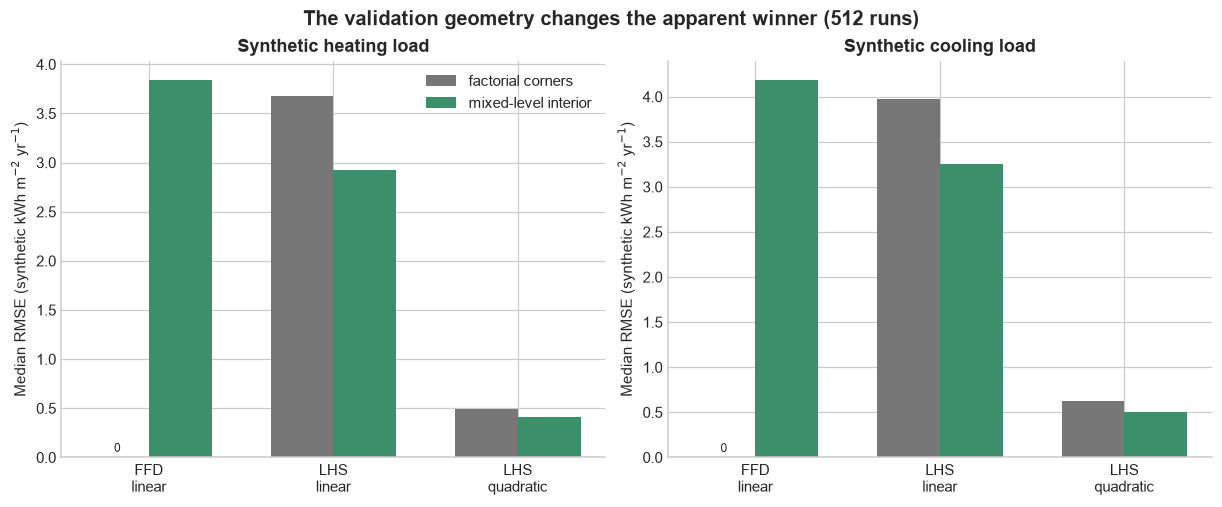

,validation,response,design,model,RMSE,MAE
0,factorial corners,Cooling,FFD,linear + 2FI,5.4537e-14,4.5373e-14
1,factorial corners,Cooling,LHS,linear + 2FI,3.9783e+00,3.2678e+00
2,factorial corners,Cooling,LHS,quadratic,6.2957e-01,5.0729e-01
3,factorial corners,Heating,FFD,linear + 2FI,2.4823e-14,1.9388e-14
4,factorial corners,Heating,LHS,linear + 2FI,3.6808e+00,3.0180e+00
5,factorial corners,Heating,LHS,quadratic,4.8763e-01,4.0009e-01
6,mixed-level interior,Cooling,FFD,linear + 2FI,4.1856e+00,2.8247e+00
7,mixed-level interior,Cooling,LHS,linear + 2FI,3.2540e+00,2.7661e+00
8,mixed-level interior,Cooling,LHS,quadratic,5.0016e-01,4.0151e-01
9,mixed-level interior,Heating,FFD,linear + 2FI,3.8416e+00,2.6653e+00


In [14]:
comparison_512 = (benchmark.query("budget == 512")
                  .groupby(["validation", "response", "design", "model"], as_index=False)
                  .agg(RMSE=("RMSE", "median"), MAE=("MAE", "median")))

order = [("FFD", "linear + 2FI"), ("LHS", "linear + 2FI"), ("LHS", "quadratic")]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, response in zip(axes, responses):
    vals = comparison_512.query("response == @response")
    x = np.arange(len(order))
    width = 0.34
    for offset, validation_name, color in [(-width/2, "factorial corners", "#777777"),
                                            (width/2, "mixed-level interior", "#3b8f6b")]:
        heights = []
        for design, model in order:
            heights.append(vals.query("validation == @validation_name and design == @design and model == @model")["RMSE"].iloc[0])
        bars = ax.bar(x + offset, heights, width, label=validation_name, color=color)
        for bar, height in zip(bars, heights):
            if height < 1e-10:
                ax.text(bar.get_x() + bar.get_width()/2, 0.03, "0", ha="center", va="bottom", fontsize=8)
    ax.set(title=f"Synthetic {response.lower()} load", ylabel=r"Median RMSE (synthetic kWh m$^{-2}$ yr$^{-1}$)",
           xticks=x, xticklabels=["FFD\nlinear", "LHS\nlinear", "LHS\nquadratic"])
axes[0].legend()
fig.suptitle("The validation geometry changes the apparent winner (512 runs)",
             fontsize=13, fontweight="bold")
plt.show()

comparison_512

### What the benchmark establishes—and what it does not

The linear-truth sanity check is essentially exact for both designs, so the demonstration does not decree that LHS must always win. Under curvature that vanishes at corners, the FFD looks excellent on factorial validation but incurs substantial interior error. LHS plus a quadratic model detects most of that curvature; the residual error comes from the deliberately documented higher-order remainder. Repeating 20 seeds reveals variability rather than showcasing a lucky LHS.

This supports the article's mechanism: **a flexible response model cannot estimate curvature that the design never varies independently**. It does not validate the numerical TRNSYS coefficients or prove that every building problem has the same curvature. A practitioner should choose the validation distribution to match intended use, not the training design.

## 8. Practitioner conclusions

- **What did DoE make possible?** It turned 10-input simulator runs into a controlled comparison of estimable model structure and prediction geometry. Resolution-V fractions estimate main effects and all two-factor interactions economically; LHS trades exact orthogonality for interior coverage and curvature estimation.
- **What would OFAT miss?** The joint WDI–SHGC and envelope interactions. OFAT also spends runs on coordinate axes rather than covering combinations used by a surrogate.
- **Which effects are supported?** In the reconstructed FFD, main effects and two-factor interactions are supported as distinct columns. Pure quadratics are not. In the LHS reconstruction, all quadratic columns are estimable, but only the unavailable responses could establish their scientific importance.
- **Which effects are merely fitted?** The article's stepwise terms are conditional on an undocumented selection path. High training $R^2$ is not evidence that a term is stable or causal.
- **Where is prediction trustworthy?** Inside the sampled region and under a validation distribution resembling intended building designs. Corner-only validation supports corner prediction, not necessarily interpolation.
- **Where is it extrapolation?** Outside every Table 3 bound. Orientation is treated numerically over 0–90°; extending beyond that range also ignores circular geometry.
- **Design limitation versus model limitation:** the FFD cannot identify pure curvature by design. LHS can identify it, but a quadratic can still miss higher-order structure. More rows do not repair an unsuitable basis automatically.
- **Most important assumptions:** deterministic simulator fidelity, fixed Seoul climate and operating schedules, WDI/SHGC discretization, negligible higher-order interactions for FFD, and a validation set representative of downstream use.
- **Mistakes to avoid:** calling residual error pure error without replication; selecting a winner using its own design geometry; confusing Equation (2) with conventional RMSE; treating generated rows as the authors' undisclosed rows; and interpreting stepwise importance rankings without stability analysis.

## 9. Reproducibility metadata

In [15]:
versions = pd.Series({
    "Python": platform.python_version(),
    "pydoe": metadata.version("pydoe"),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "random seed": SEED,
    "LHS benchmark repeats": 20,
    "execution date": EXECUTION_DATE,
    "source PDF SHA-256": "d71d000a2f28ccbda95008a58d34e70dbf7c8d916f9ce273d769c1a6ec8d59c0",
})

# Final executable quality gates.
assert np.linalg.matrix_rank(model_matrix(ffd_train[512], False)[0]) == 56
assert np.linalg.matrix_rank(model_matrix(ffd_train[512], True)[0]) == 56
assert np.linalg.matrix_rank(model_matrix(lhs_train[128], True)[0]) == 66
assert benchmark.isna().sum().sum() == 0
assert (benchmark[["RMSE", "MAE"]] >= 0).all().all()
assert len(benchmark.query("design == 'LHS' and repeat >= 0")["repeat"].unique()) == 20

versions.to_frame("value")

,value
Python,3.13.2
pydoe,1.3.1.dev11+geca1a2598
numpy,2.3.4
pandas,3.0.0
matplotlib,3.11.1
random seed,20210801
LHS benchmark repeats,20
execution date,2026-08-01
source PDF SHA-256,d71d000a2f28ccbda95008a58d34e70dbf7c8d916f9ce2...
